# **1. Perkenalan Dataset**


---

1. Boston Housing Dataset

**Kaggle – Boston Housing Dataset**  
https://www.kaggle.com/datasets/altavish/boston-housing-dataset/code

Merupakan kumpulan data yang digunakan di dunia statistik dan machine learning, khususnya sebagai benchmark dalam pemodelan regresi untuk memprediksi harga perumahan. Dataset ini awalnya dikumpulkan oleh U.S. Census Service dan diarsipkan di StatLib, dengan sejumlah 506 observasi mengenai properti di wilayah Boston.

---

2. Referensi Literatur atau Jurnal yang Relevan

**Harrison, D., & Rubinfeld, D. L. (1978). "Hedonic Housing Prices and the Demand for Clean Air." Journal of Environmental Economics and Management, 5(1), 81-102.**  
   - **Jurnal:** Journal of Big Data  
   - **Link:**   [Hedonic Housing Prices and the Demand for Clean Air (UMich Library)](https://hdl.handle.net/2027.42/22636

  Penelitian ini adalah salah satu studi yang menggunakan pendekatan model hedonic untuk mengaitkan karakteristik lingkungan dengan harga perumahan. Hasil karya ini menjadi landasan penting dalam mengaplikasikan analisis regresi pada data perumahan dan menginspirasi penggunaan Boston Housing Dataset dalam banyak studi selanjutnya.

---

# **2. Import Library**

In [37]:
# Impor library dasar
import pandas as pd
import numpy as np

# Library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Setting style agar grafik lebih menarik
sns.set(style="whitegrid")
%matplotlib inline

from sklearn.model_selection import train_test_split  # Untuk membagi data menjadi training dan test-set
from sklearn.preprocessing import StandardScaler      # Untuk menstandardisasi fitur


# **3. Memuat Dataset**

In [20]:
# URL dataset dari Github (raw CSV)
url = "https://raw.githubusercontent.com/ulfasyabania/Eksperimen_SML_ulfasyabania/refs/heads/main/BostonHousing_raw.csv"

# Membaca dataset menggunakan pandas
df = pd.read_csv(url)

# Menampilkan 5 baris pertama untuk memastikan dataset telah termuat dengan benar
print(df.head())


      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  


**Periksa Informasi Umum Dataset**

In [21]:
# Menampilkan informasi umum mengenai dataframe
df.info()

# Melihat ukuran dataset (jumlah baris dan kolom)
print("Shape dari dataset:", df.shape)

# Melihat statistik deskriptif dari dataset
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
Shape dari dataset: (506, 14)
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  486.000000  486.000000  486.000000  486.000000  506.000000  506.000000   
mean     3.611874   11.211934   11.083992  

# **4. Exploratory Data Analysis (EDA)**

**Mengecek Missing Values dan Duplikasi**

In [22]:
# Mengecek missing values per kolom
print("\nCek Missing Values:")
print(df.isnull().sum())

# Mengecek apakah ada duplikasi baris
duplicate_count = df.duplicated().sum()
print("\nJumlah Data Duplikat:", duplicate_count)

# Jika ada duplikasi, hapus baris duplikat (opsional)
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplikasi telah dihapus. Ukuran baru dataset:", df.shape)



Cek Missing Values:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

Jumlah Data Duplikat: 0


**Visualisasi Distribusi Variabel Target**

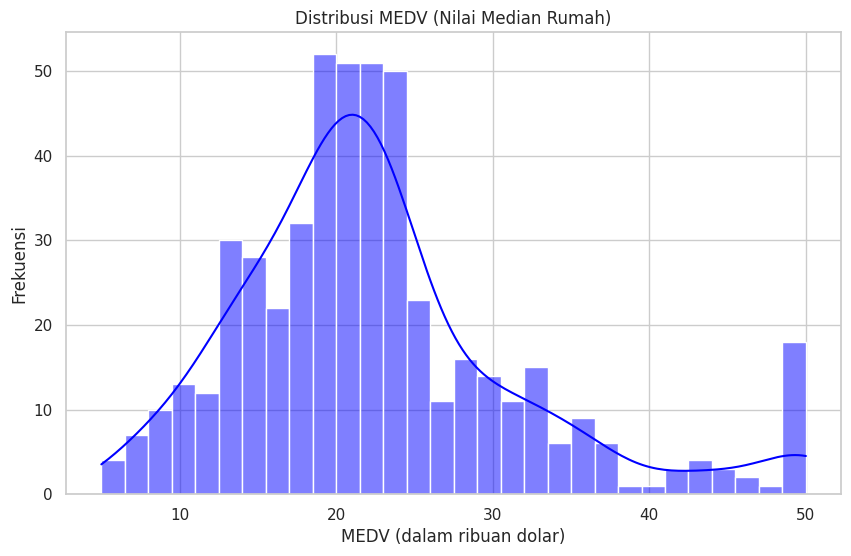

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(df['MEDV'], bins=30, kde=True, color='blue')
plt.title("Distribusi MEDV (Nilai Median Rumah)")
plt.xlabel("MEDV (dalam ribuan dolar)")
plt.ylabel("Frekuensi")
plt.show()


**Visualisasi Distribusi Variabel-Fitur**

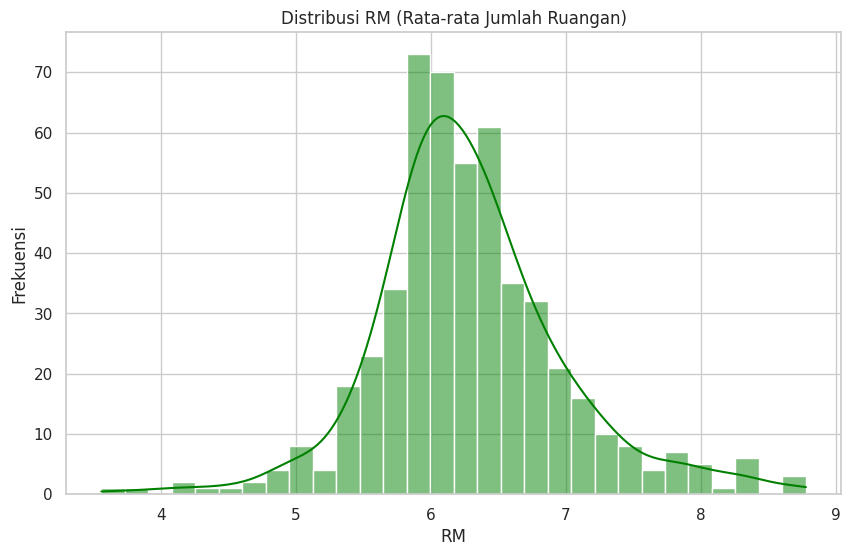

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df['RM'], bins=30, kde=True, color='green')
plt.title("Distribusi RM (Rata-rata Jumlah Ruangan)")
plt.xlabel("RM")
plt.ylabel("Frekuensi")
plt.show()


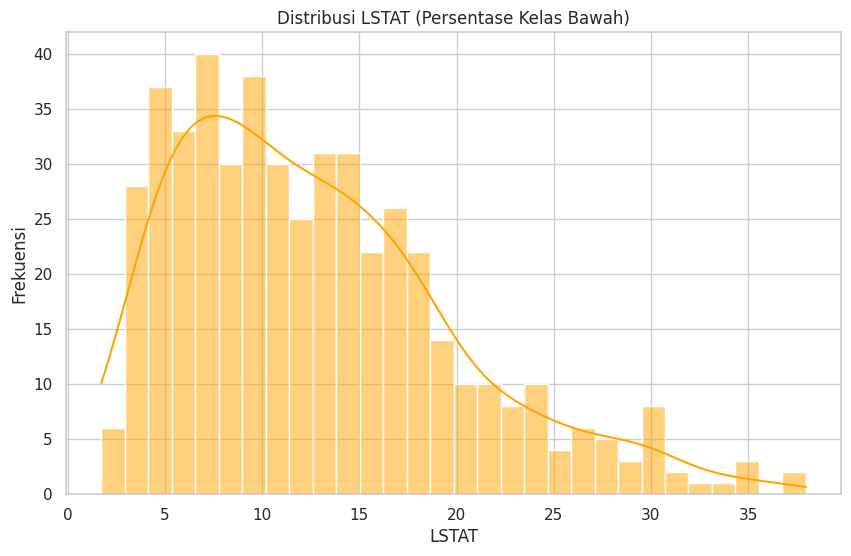

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df['LSTAT'], bins=30, kde=True, color='orange')
plt.title("Distribusi LSTAT (Persentase Kelas Bawah)")
plt.xlabel("LSTAT")
plt.ylabel("Frekuensi")
plt.show()


**Analisis Outlier dengan Boxplot**

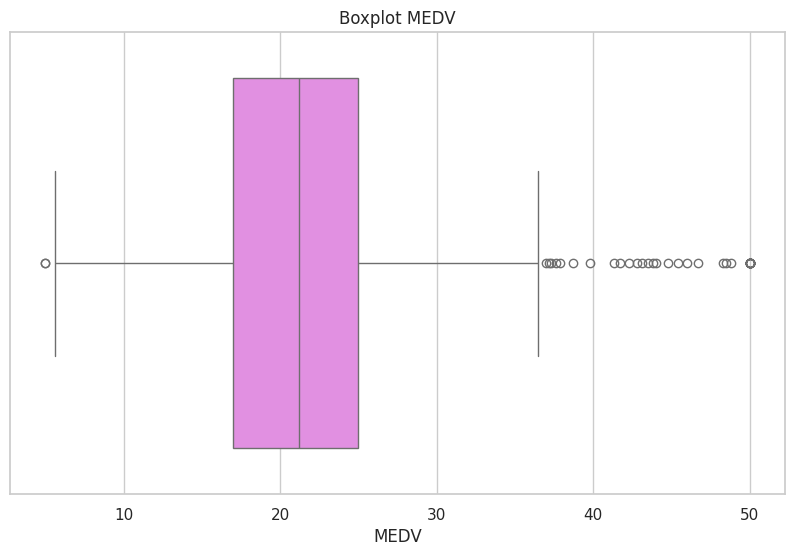

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['MEDV'], color='violet')
plt.title("Boxplot MEDV")
plt.xlabel("MEDV")
plt.show()


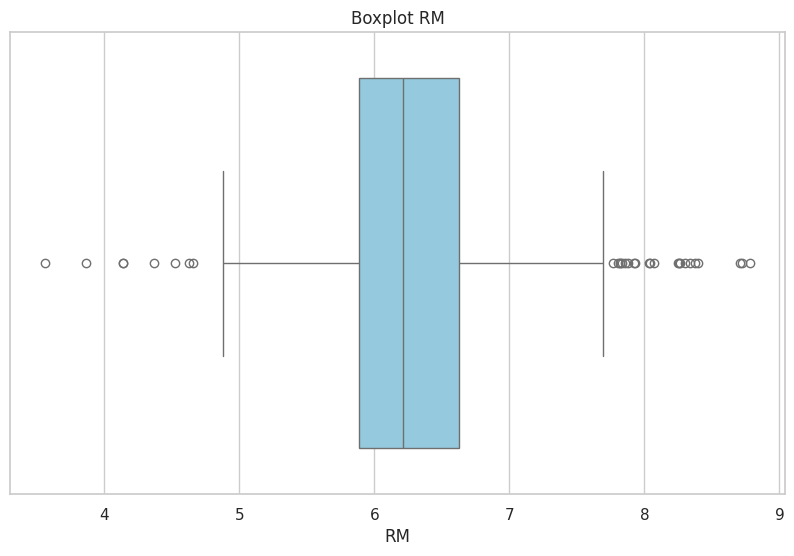

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['RM'], color='skyblue')
plt.title("Boxplot RM")
plt.xlabel("RM")
plt.show()


**Analisis Korelasi Antar Fitur**

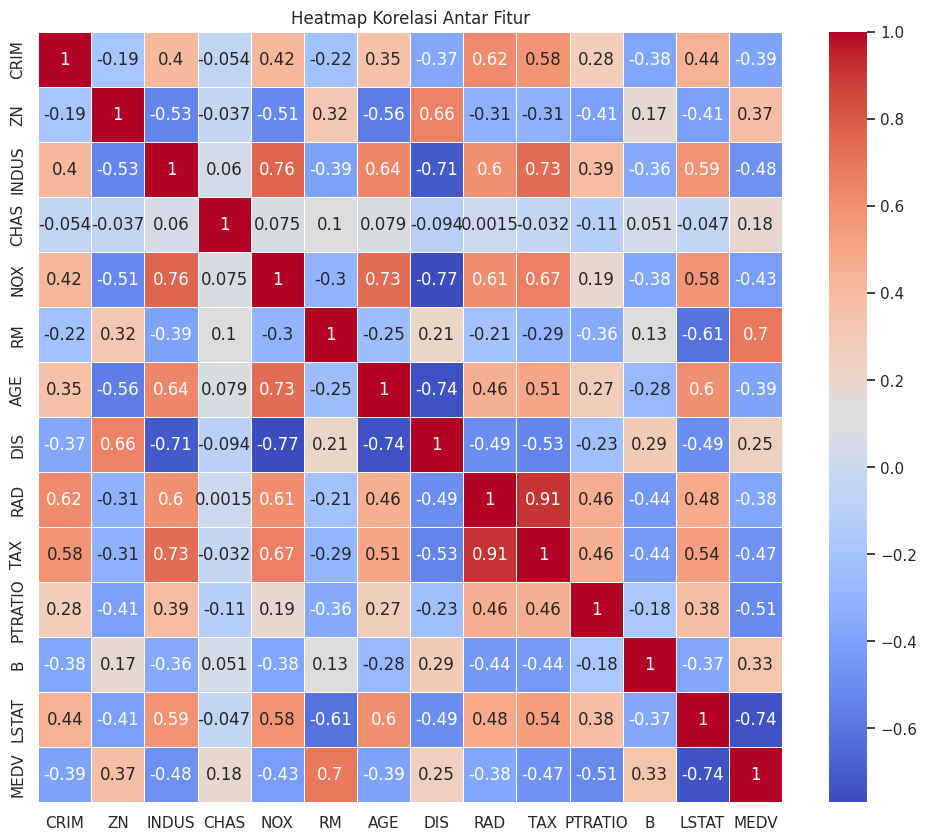

In [29]:
# Hitung matriks korelasi
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()


**Scatter Plot untuk Analisis Hubungan Antar Fitur**

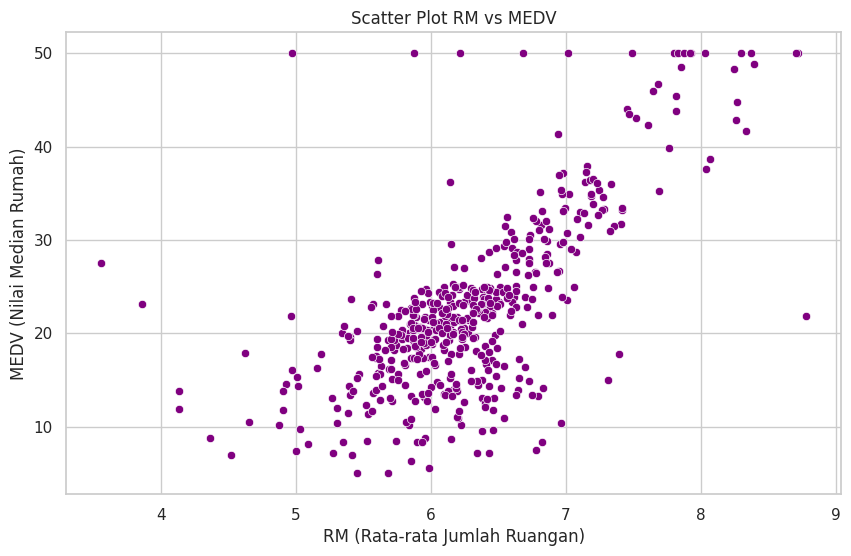

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="RM", y="MEDV", data=df, color='purple')
plt.title("Scatter Plot RM vs MEDV")
plt.xlabel("RM (Rata-rata Jumlah Ruangan)")
plt.ylabel("MEDV (Nilai Median Rumah)")
plt.show()


**Pairplot untuk Visualisasi Hubungan Multivariat**

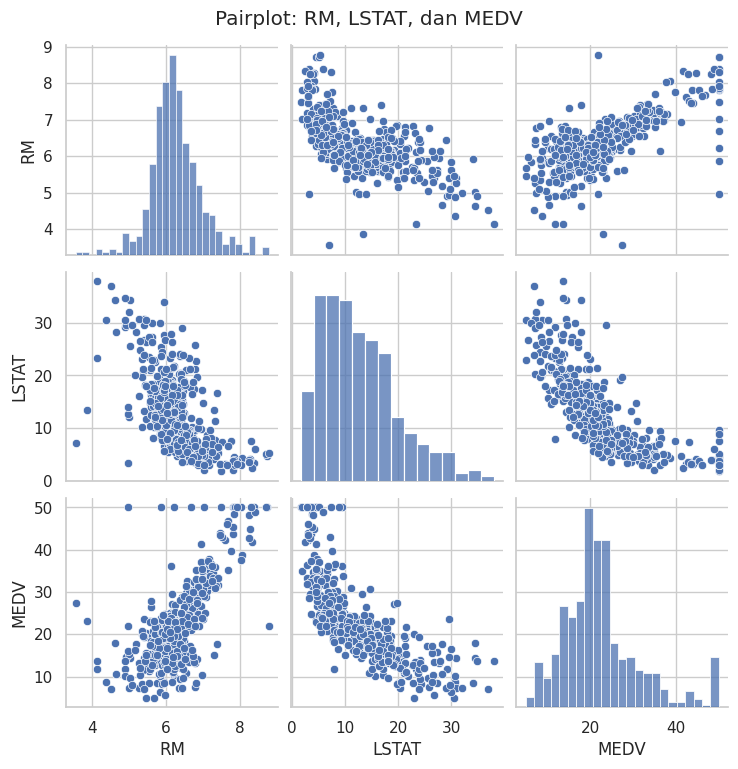

In [31]:
# Kita gunakan subset fitur RM, LSTAT, dan MEDV
sns.pairplot(df[['RM', 'LSTAT', 'MEDV']])
plt.suptitle("Pairplot: RM, LSTAT, dan MEDV", y=1.02)
plt.show()


# **5. Data Preprocessing**

**Menangani Missing Values**

In [14]:
# Mengisi missing values dengan nilai median untuk tiap kolom
df.fillna(df.median(), inplace=True)

# Verifikasi kembali bahwa tidak ada missing values
print("\nJumlah Missing Values setelah imputasi:")
print(df.isnull().sum())



Jumlah Missing Values setelah imputasi:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


**Memisahkan Fitur (X) dan Target (y)**

In [15]:
# Memisahkan variabel input (fitur) dan target
X = df.drop('MEDV', axis=1)   # Semua kolom kecuali 'MEDV' sebagai fitur
y = df['MEDV']                # Target variabel


**Membagi Data Menjadi Training dan Testing Set**

In [16]:
# Membagi dataset ke dalam training set dan testing set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nDimensi Training Set:", X_train.shape)
print("Dimensi Testing Set:", X_test.shape)



Dimensi Training Set: (404, 13)
Dimensi Testing Set: (102, 13)


**Feature Scaling (Standardisasi)**

In [17]:
# Inisialisasi StandardScaler
scaler = StandardScaler()

# Melakukan fitting dan transformasi pada training set
X_train_scaled = scaler.fit_transform(X_train)

# Transformasi pada testing set menggunakan scaler yang telah di-fit pada training set
X_test_scaled = scaler.transform(X_test)

# Menampilkan ringkasan statistik sederhana dari fitur yang telah discale
print("\nRata-rata dan standar deviasi (setelah scaling) pada training set:")
print("Mean:", X_train_scaled.mean(axis=0))
print("Std Dev:", X_train_scaled.std(axis=0))



Rata-rata dan standar deviasi (setelah scaling) pada training set:
Mean: [ 4.83661516e-17  2.41830758e-17  2.44029219e-16  2.41830758e-17
 -5.11142284e-16 -2.61616911e-16 -2.83601525e-16  5.24882668e-17
 -9.45338417e-17 -1.51693839e-16  8.51903806e-16 -4.94653823e-16
  6.59538430e-18]
Std Dev: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Validasi Nilai dan Tipe Data Kolom CHAS**

In [32]:
# Tampilkan nilai unik dari kolom CHAS
print("Nilai unik pada kolom CHAS:", df['CHAS'].unique())


Nilai unik pada kolom CHAS: [ 0. nan  1.]


**Konversi Tipe Data Menjadi Kategori**

In [34]:
# Terapkan one-hot encoding hanya untuk kolom CHAS
df_encoded = pd.get_dummies(df, columns=['CHAS'], drop_first=True)

# Tampilkan 5 baris pertama hasil encoding
print("Contoh data setelah one-hot encoding pada kolom CHAS:")
print(df_encoded.head())


Contoh data setelah one-hot encoding pada kolom CHAS:
      CRIM    ZN  INDUS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  CHAS_1.0  
0  396.90   4.98  24.0     False  
1  396.90   9.14  21.6     False  
2  392.83   4.03  34.7     False  
3  394.63   2.94  33.4     False  
4  396.90    NaN  36.2     False  


In [35]:
# Pisahkan fitur (X) dan target (y)
X = df.drop('MEDV', axis=1)
y = df['MEDV']

# Pisahkan fitur numerik dan kategori
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['category']).columns.tolist()

print("Fitur Numerik:", numerical_features)
print("Fitur Kategori:", categorical_features)

# Lakukan scaling hanya pada fitur numerik
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X[numerical_features])

# Gabungkan kembali dengan fitur kategori secara horizontal
# Ubah array scaled ke DataFrame dan pastikan index-nya sama
X_num_scaled_df = pd.DataFrame(X_num_scaled, columns=numerical_features, index=X.index)

# Hasil akhir data preprocessing: fitur numerik scaled dan fitur kategori dibiarkan dalam bentuk aslinya.
X_processed = pd.concat([X_num_scaled_df, X[categorical_features]], axis=1)
print("Contoh data setelah memproses fitur numerik dan kategori:")
print(X_processed.head())


Fitur Numerik: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Fitur Kategori: []
Contoh data setelah memproses fitur numerik dan kategori:
       CRIM        ZN     INDUS      CHAS       NOX        RM       AGE  \
0 -0.413898  0.290525 -1.284840 -0.274265 -0.144217  0.413672 -0.118643   
1 -0.411488 -0.479864 -0.587798 -0.274265 -0.740262  0.194274  0.371156   
2 -0.411491 -0.479864 -0.587798 -0.274265 -0.740262  1.282714 -0.265225   
3 -0.410908 -0.479864 -1.303877 -0.274265 -0.835284  1.016303 -0.812226   
4 -0.406697 -0.479864 -1.303877 -0.274265 -0.835284  1.228577 -0.511911   

        DIS       RAD       TAX   PTRATIO         B     LSTAT  
0  0.140214 -0.982843 -0.666608 -1.459000  0.441052 -1.082105  
1  0.557160 -0.867883 -0.987329 -0.303094  0.441052 -0.500165  
2  0.557160 -0.867883 -0.987329 -0.303094  0.396427 -1.215000  
3  1.077737 -0.752922 -1.106115  0.113032  0.416163 -1.367479  
4  1.077737 -0.752922 -1.106115  0.1130

In [38]:
# Menggabungkan Fitur Terpreprocessing dengan Target
df_processed = X_processed.copy()
df_processed['MEDV'] = y

# Verifikasi beberapa baris data yang sudah dipreprocessing
print("\nContoh data akhir yang akan disimpan:")
print(df_processed.head())

# Menyimpan Data ke File CSV ---
csv_filename = "BostonHousing_preprocessed.csv"
df_processed.to_csv(csv_filename, index=False)
print(f"\nFile CSV '{csv_filename}' telah disimpan.")


Contoh data akhir yang akan disimpan:
       CRIM        ZN     INDUS      CHAS       NOX        RM       AGE  \
0 -0.413898  0.290525 -1.284840 -0.274265 -0.144217  0.413672 -0.118643   
1 -0.411488 -0.479864 -0.587798 -0.274265 -0.740262  0.194274  0.371156   
2 -0.411491 -0.479864 -0.587798 -0.274265 -0.740262  1.282714 -0.265225   
3 -0.410908 -0.479864 -1.303877 -0.274265 -0.835284  1.016303 -0.812226   
4 -0.406697 -0.479864 -1.303877 -0.274265 -0.835284  1.228577 -0.511911   

        DIS       RAD       TAX   PTRATIO         B     LSTAT  MEDV  
0  0.140214 -0.982843 -0.666608 -1.459000  0.441052 -1.082105  24.0  
1  0.557160 -0.867883 -0.987329 -0.303094  0.441052 -0.500165  21.6  
2  0.557160 -0.867883 -0.987329 -0.303094  0.396427 -1.215000  34.7  
3  1.077737 -0.752922 -1.106115  0.113032  0.416163 -1.367479  33.4  
4  1.077737 -0.752922 -1.106115  0.113032  0.441052       NaN  36.2  

File CSV 'BostonHousing_preprocessed.csv' telah disimpan.
